# Sprint 13 - Previsões e Predições

## Initialization and Preview

In [1]:
# import libraries
import pandas as pd 
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import accuracy_score, precision_score, recall_score, silhouette_score



pd.set_option('display.precision', 15)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 300)


In [2]:
import warnings
warnings.filterwarnings('ignore')


In [3]:
# load data & preview
df = pd.read_csv('https://code.s3.yandex.net/datasets/gym_churn.csv')
df.info()
print()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470422861144,5.0,3,0.020397947620858,0.000000000000000,0
1,0,1,0,0,1,12,1,31,113.202937651058207,12.0,7,1.922936055041820,1.910243521519641,0
2,0,1,1,0,1,1,0,28,129.448479332006144,1.0,2,1.859098347383238,1.736501891634414,0
3,0,1,1,1,1,12,1,33,62.669863191238292,12.0,2,3.205632768238500,3.357214513052662,0
4,1,1,1,1,1,1,0,26,198.362265439036833,1.0,3,1.113884400425780,1.120078107422207,0


## Exploratory Data Analysis (EDA)

In [4]:
df.columns

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='object')

In [5]:
df.shape

(4000, 14)

In [6]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000000000000,4000.000000000000000,4000.00000000000000,4000.000000000000000,4000.000000000000000,4000.00000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000,4000.000000000000000
mean,0.510250000000000,0.845250000000000,0.48675000000000,0.308500000000000,0.903500000000000,4.68125000000000,0.412250000000000,29.184249999999999,146.943727809250021,4.322750000000000,3.724750000000000,1.879019712534937,1.767051822040508,0.265250000000000
std,0.499957425044087,0.361711412989101,0.49988689643489,0.461931916275352,0.295312634995689,4.54970585789327,0.492301256987942,3.258367102790006,96.355602395679838,4.191297434094276,3.749266820049219,0.972244872030617,1.052905717489531,0.441521429596796
min,0.000000000000000,0.000000000000000,0.00000000000000,0.000000000000000,0.000000000000000,1.00000000000000,0.000000000000000,18.000000000000000,0.148204788456624,1.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000
25%,0.000000000000000,1.000000000000000,0.00000000000000,0.000000000000000,1.000000000000000,1.00000000000000,0.000000000000000,27.000000000000000,68.868829978416670,1.000000000000000,1.000000000000000,1.180875086219582,0.963002948193214,0.000000000000000
50%,1.000000000000000,1.000000000000000,0.00000000000000,0.000000000000000,1.000000000000000,1.00000000000000,0.000000000000000,29.000000000000000,136.220158971036881,1.000000000000000,3.000000000000000,1.832768412113406,1.719574310109868,0.000000000000000
75%,1.000000000000000,1.000000000000000,1.00000000000000,1.000000000000000,1.000000000000000,6.00000000000000,1.000000000000000,31.000000000000000,210.949624655502134,6.000000000000000,5.000000000000000,2.536078338329289,2.510336265936281,1.000000000000000
max,1.000000000000000,1.000000000000000,1.00000000000000,1.000000000000000,1.000000000000000,12.00000000000000,1.000000000000000,41.000000000000000,552.590740386879816,12.000000000000000,31.000000000000000,6.023668475995910,6.146782880452392,1.000000000000000


In [7]:
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037427696495,0.873086083701939,0.534195304525349,0.353521605988431,0.903708744470908,5.747192922762845,0.464103436543042,29.976522626743790,158.445714801611530,5.283089486219803,4.711806736985369,2.024875642518551,2.027881733095180
1,0.510838831291235,0.768143261074458,0.355325164938737,0.183788878416588,0.902921771913289,1.728557964184731,0.268614514608860,26.989632422243165,115.082898619287278,1.662582469368520,0.990574929311970,1.474994662372975,1.044545593398017


In [8]:
# Function to create graphs
def display_graph(df, col_name):
    for col in df.columns:
        if col == col_name: continue  # skip target column

        plt.figure(figsize=(6,4))
        # bar chart for binary variables
        if df[col].nunique() <= 2:
            sns.countplot(
                data=df,
                x=col,
                hue=col_name,
                palette="Set1"
            )

        # Histogram for continuous variables
        else:
            sns.histplot(
                data=df,
                x=col,   # column to be graphed
                hue=col_name, 
                kde=True,
                palette="Set1",
                alpha=0.5
            )

        plt.title(f"{col} by{col_name}")
        plt.tight_layout()
        plt.show()

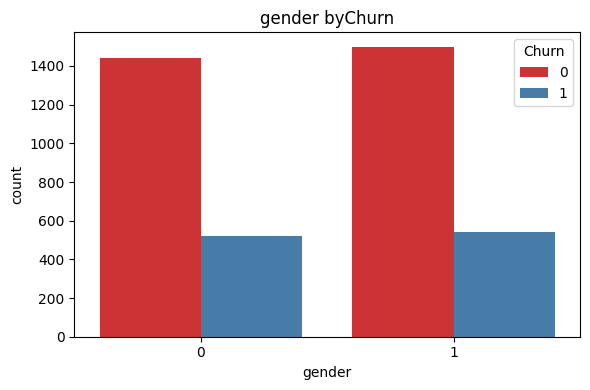

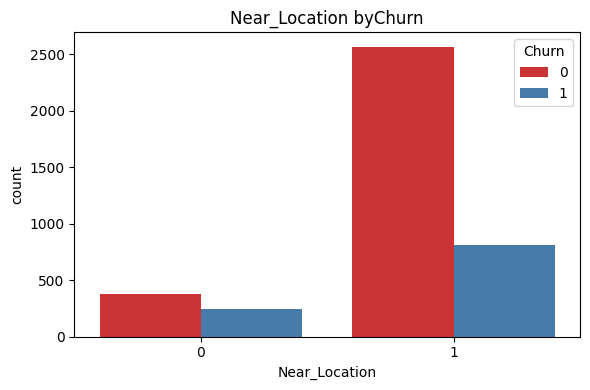

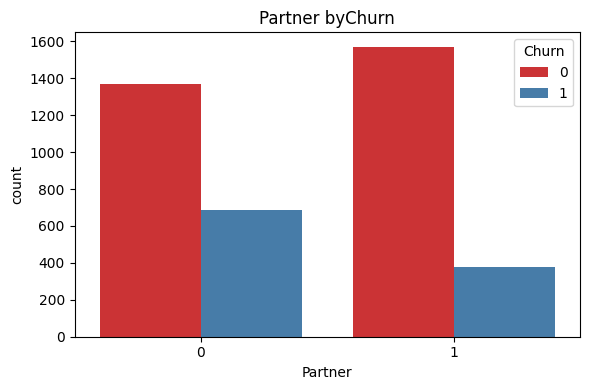

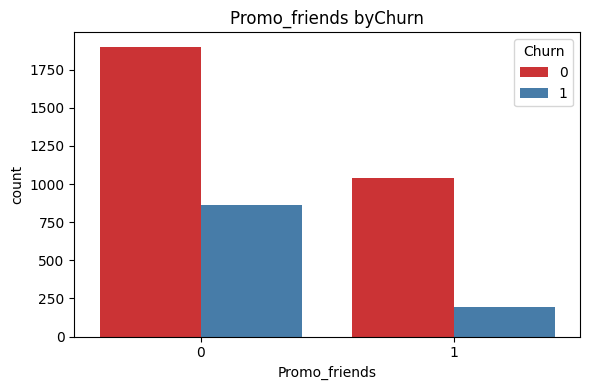

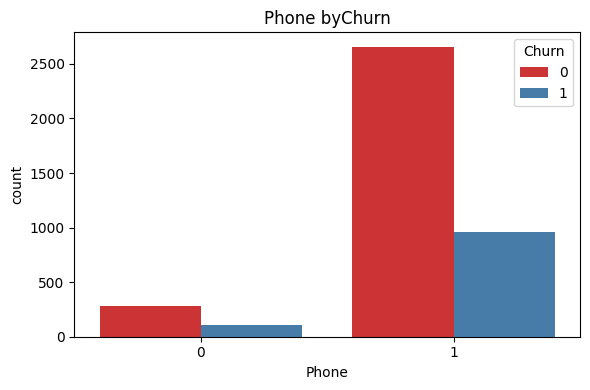

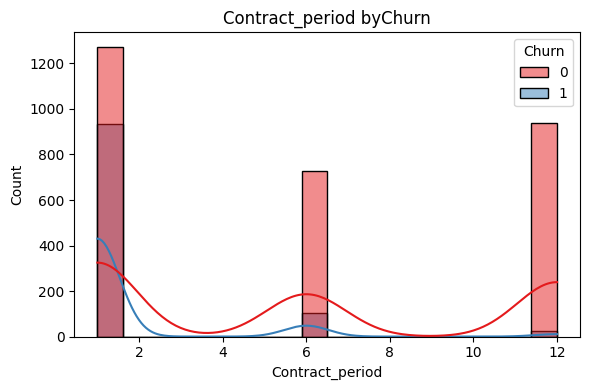

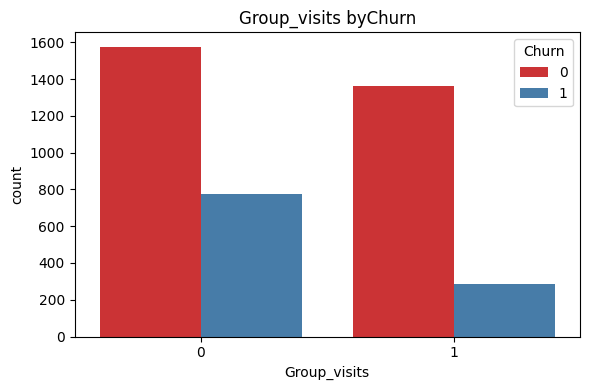

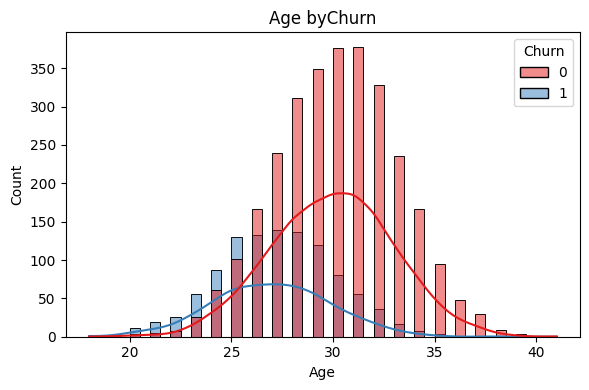

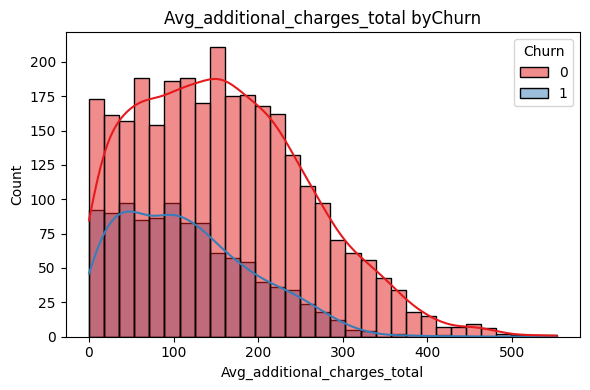

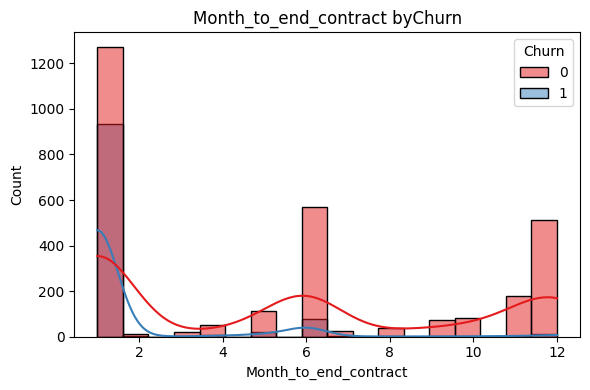

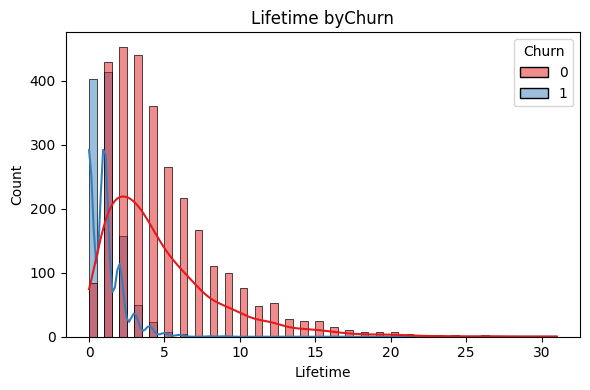

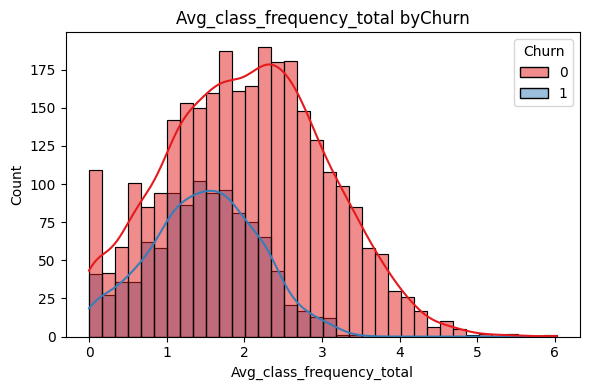

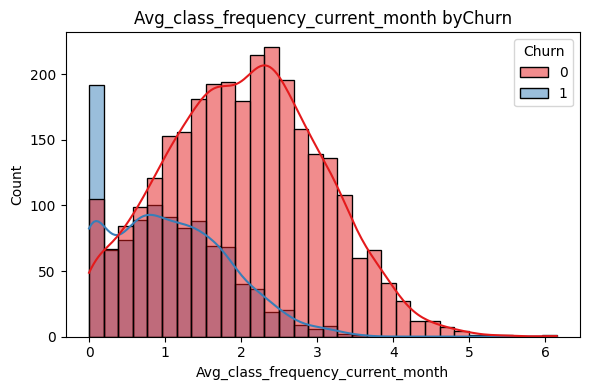

In [9]:
# explore features
display_graph(df, 'Churn')


In [10]:
df.corr()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000000000000,0.006699227595081,-0.010462622250800,-0.005033272441054,-0.008542118064000,0.000502261220279,0.017878940218984,0.013806900920360,-0.009334436022097,-0.001280790522073,0.013578571154470,0.014620159193698,0.009156488375539,0.000707733985153
Near_Location,0.006699227595081,1.000000000000000,-0.005119431260763,0.210964279250089,-0.015763230257229,0.150232831416567,0.154728047973810,0.058357839446367,0.040761205686103,0.143960652863483,0.070920564055164,0.043127478605891,0.062663633458793,-0.128097990299810
Partner,-0.010462622250800,-0.005119431260763,1.000000000000000,0.451959803638693,0.009969610205313,0.306166251238889,0.022709566916954,0.047479698759628,0.022941185300935,0.294632124877685,0.061229353260985,0.024937869800103,0.045561091361999,-0.157985736985098
Promo_friends,-0.005033272441054,0.210964279250089,0.451959803638693,1.000000000000000,0.001981592231935,0.244551568070672,0.120169506269850,0.050113307413902,0.036897676000240,0.239553224750288,0.072721100932983,0.028063220773726,0.053768377063076,-0.162233077833515
Phone,-0.008542118064000,-0.015763230257229,0.009969610205313,0.001981592231935,1.000000000000000,-0.006893264000346,-0.010099146860770,-0.011403238953259,0.009279431489794,-0.011196256833938,-0.018801227382775,0.008340465501805,0.013374852916164,-0.001176601362480
Contract_period,0.000502261220279,0.150232831416567,0.306166251238889,0.244551568070672,-0.006893264000346,1.000000000000000,0.169990834019106,0.138249289429536,0.111445063341492,0.973063587268638,0.170725270972972,0.096211136398092,0.159407376566591,-0.389984211586078
Group_visits,0.017878940218984,0.154728047973810,0.022709566916954,0.120169506269850,-0.010099146860770,0.169990834019106,1.000000000000000,0.080933568901738,0.032079086460016,0.163702563158596,0.075852846038239,0.056694752430919,0.075923274727096,-0.175324655498149
Age,0.013806900920360,0.058357839446367,0.047479698759628,0.050113307413902,-0.011403238953259,0.138249289429536,0.080933568901738,1.000000000000000,0.080240125272997,0.134511341398497,0.164692820019427,0.119953132113990,0.183094542154536,-0.404735252823589
Avg_additional_charges_total,-0.009334436022097,0.040761205686103,0.022941185300935,0.036897676000240,0.009279431489794,0.111445063341492,0.032079086460016,0.080240125272997,1.000000000000000,0.113958039016871,0.079028338696600,0.044426412947373,0.079569677409450,-0.198697451068203
Month_to_end_contract,-0.001280790522073,0.143960652863483,0.294632124877685,0.239553224750288,-0.011196256833938,0.973063587268638,0.163702563158596,0.134511341398497,0.113958039016871,1.000000000000000,0.161077551415275,0.085386674018559,0.147605112323244,-0.381392983695714


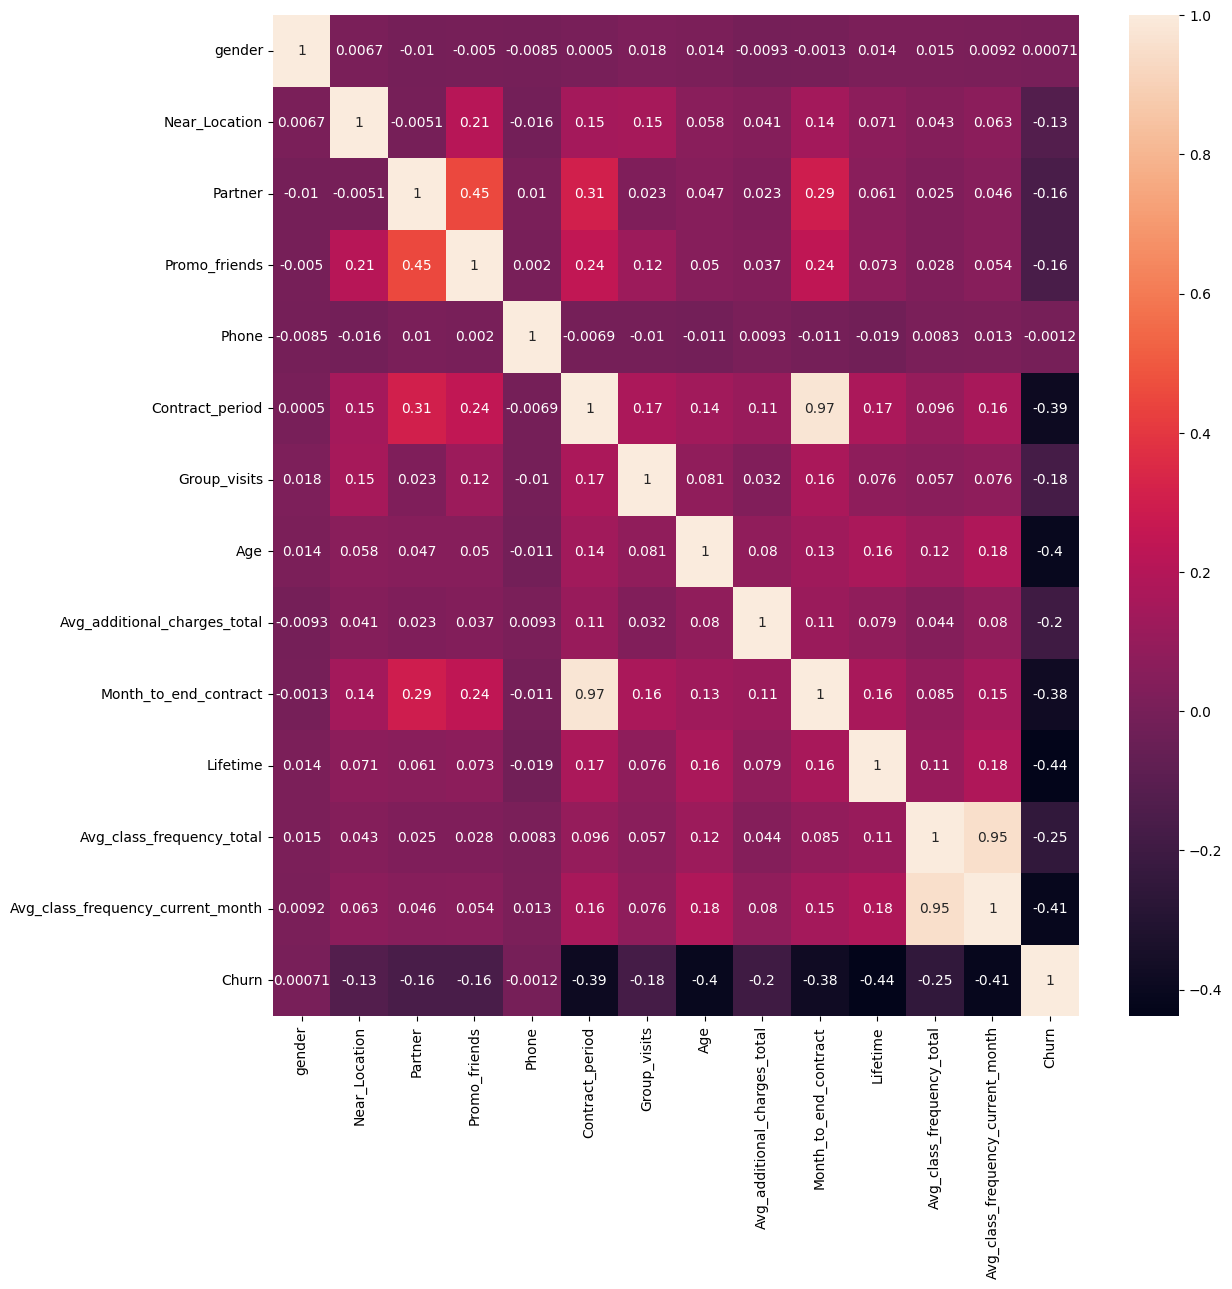

In [11]:
plt.figure(figsize = (13,13))
sns.heatmap(df.corr(), annot = True)
plt.show()


In [12]:
# OPTIONAL: not explained in the course
# Calculate the mutual information between each feature and the target variable 'Churn'.
# Mutual information works with binary variables and captures nonlinear relationships.
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=['Churn'])
y = df['Churn']

mi = mutual_info_classif(X, y, discrete_features='auto')
pd.Series(mi, index=X.columns).sort_values(ascending=False)

Lifetime                             0.207526041222873
Contract_period                      0.100516561058366
Age                                  0.098703266015891
Avg_class_frequency_current_month    0.096860544501369
Month_to_end_contract                0.093961403126471
Avg_class_frequency_total            0.057969923714796
Avg_additional_charges_total         0.025032234280908
Promo_friends                        0.023682970400739
Partner                              0.015103282387832
Group_visits                         0.013988203509201
Phone                                0.011961555756433
gender                               0.002725652229917
Near_Location                        0.000000000000000
dtype: float64

 ## Churn prediction

In [13]:
# delete unrelated columns
df_model = df.drop(columns = ["gender", "Phone"])

# verify change
df_model.columns

Index(['Near_Location', 'Partner', 'Promo_friends', 'Contract_period',
       'Group_visits', 'Age', 'Avg_additional_charges_total',
       'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total',
       'Avg_class_frequency_current_month', 'Churn'],
      dtype='object')

In [14]:
# split data
X_train, X_val, y_train, y_val = train_test_split(
                                    df_model.drop(columns = ['Churn']), 
                                    df_model['Churn'], 
                                    test_size = 0.2, random_state=1234)

In [15]:
# select non-boolean numeric columns, training set
numeric_cols = [col for col in X_train.columns if df_model[col].nunique() > 2]
other_cols = X_train.drop(columns=numeric_cols)

# select boolean columns, validation set
other_cols_valid = X_val.drop(columns=numeric_cols)
other_cols_valid.head(3)

,Near_Location,Partner,Promo_friends,Group_visits
1760,1,1,1,1
3399,1,1,0,1
979,0,0,0,0


In [16]:
# Scale training data
scaler = StandardScaler()

scaled_train = pd.DataFrame( scaler.fit_transform(X_train[numeric_cols]), 
                              columns=numeric_cols,
                              index=X_train.index )

# join scaled columns with the rest
X_train_scaled = pd.concat([other_cols, scaled_train], axis=1)
X_train_scaled.head(3)

,Near_Location,Partner,Promo_friends,Group_visits,Contract_period,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
1623,1,0,0,0,-0.801119555242249,0.257050200426630,0.473025661245695,-0.783948465629340,-0.439432218571758,1.235955631201096,1.305418959810731
2229,0,1,0,0,0.298375459672486,-0.359561974509815,-0.456712760225372,0.407688951249763,-0.439432218571758,-0.174871990845583,-0.082323731943913
205,1,1,0,1,1.617769477570169,-0.051255887041593,1.267430611292796,1.599326368128866,-0.711579131563751,-0.845094370473018,-0.750309009588873


In [17]:
# Scale validation data
scaled_valid = pd.DataFrame( scaler.transform(X_val[numeric_cols]), 
                              columns=numeric_cols,
                              index=X_val.index )

# join scaled columns with the rest
X_valid_scaled = pd.concat([other_cols_valid, scaled_valid], axis=1)
X_valid_scaled.head(3)

,Near_Location,Partner,Promo_friends,Group_visits,Contract_period,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
1760,1,1,1,1,1.617769477570169,-0.667868061978038,-0.923193650027063,1.599326368128866,1.737743085364183,1.318474190160775,1.173982189781827
3399,1,1,0,1,1.617769477570169,0.565356287894853,0.812835327694118,1.837653851504686,-0.167285305579766,0.283295246789457,0.428356944895841
979,0,0,0,0,-0.801119555242249,-0.051255887041593,0.069517372728559,-0.783948465629340,-0.983726044555744,-0.390746625931503,-0.986870104879599


### Logistic Regression model

#### Unscaled data

In [18]:
# train model
lr_model = LogisticRegression(max_iter=500, random_state = 1234)
lr_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1234
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [19]:
yt_pred_lr  = lr_model.predict(X_train)

acclr_t  = round( accuracy_score(y_train, yt_pred_lr) , 2)
preclr_t = round( precision_score(y_train, yt_pred_lr), 2)
reclr_t  = round( recall_score(y_train, yt_pred_lr)   , 2)

# Training set: evaluate accuracy, precision and recall
print('Accuracy score for logistic regression is:', acclr_t)
print('Precision score for logistic regression is:', preclr_t)
print('Recall score for logistic regression is: ',reclr_t)

Accuracy score for logistic regression is: 0.93
Precision score for logistic regression is: 0.89
Recall score for logistic regression is:  0.84


In [20]:
y_pred_lr  = lr_model.predict(X_val)

acclr_v  = round( accuracy_score(y_val, y_pred_lr) , 2)
preclr_v = round( precision_score(y_val, y_pred_lr), 2)
reclr_v  = round( recall_score(y_val, y_pred_lr)   , 2)


# Validation set: evaluate accuracy, precision and recall
print('Accuracy score for logistic regression is:', acclr_v)
print('Precision score for logistic regression is:', preclr_v)
print('Recall score for logistic regression is:', reclr_v)

Accuracy score for logistic regression is: 0.94
Precision score for logistic regression is: 0.9
Recall score for logistic regression is: 0.83


#### Scaled data

In [21]:
# train model
lr_model2 = LogisticRegression(random_state = 1234)
lr_model2.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1234
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
yt_pred_lr2  = lr_model2.predict(X_train_scaled)

acclr_t2  = round( accuracy_score(y_train, yt_pred_lr2) , 2)
preclr_t2 = round( precision_score(y_train, yt_pred_lr2), 2)
reclr_t2  = round( recall_score(y_train, yt_pred_lr2)   , 2)

# Training set: evaluate accuracy, precision and recall
print('Accuracy score for logistic regression is:', acclr_t2)
print('Precision score for logistic regression is:', preclr_t2)
print('Recall score for logistic regression is: ',reclr_t2)

Accuracy score for logistic regression is: 0.93
Precision score for logistic regression is: 0.89
Recall score for logistic regression is:  0.84


In [23]:
y_pred_lr2  = lr_model2.predict(X_valid_scaled)

# Validation set: evaluate accuracy, precision and recall
acclr_v2  = round( accuracy_score(y_val, y_pred_lr2) , 2)
preclr_v2 = round( precision_score(y_val, y_pred_lr2), 2)
reclr_v2  = round( recall_score(y_val, y_pred_lr2)   , 2)

print('Accuracy score for logistic regression is:', acclr_v2)
print('Precision score for logistic regression is:', preclr_v2)
print('Recall score for logistic regression is:', reclr_v2)

Accuracy score for logistic regression is: 0.94
Precision score for logistic regression is: 0.9
Recall score for logistic regression is: 0.83


 ### Random forest model

In [24]:
# train model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                  min_samples_leaf=5, random_state = 1234)
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
yt_pred_rf  = rf_model.predict(X_train)

accrf_t  = round( accuracy_score(y_train, yt_pred_rf) , 2)
precrf_t = round( precision_score(y_train, yt_pred_rf), 2)
recrf_t  = round( recall_score(y_train, yt_pred_rf)   , 2)

# Training set: evaluate accuracy, precision and recall
print('Accuracy score for random forest is:', accrf_t)
print('Precision score for random forest is:', precrf_t)
print('Recall score for random forest is:', recrf_t)


Accuracy score for random forest is: 0.95
Precision score for random forest is: 0.93
Recall score for random forest is: 0.88


In [26]:
y_pred_rf = rf_model.predict(X_val)

# Validation set: evaluate accuracy, precision and recall
accrf_v  = round( accuracy_score(y_val, y_pred_rf) , 2)
precrf_v = round( precision_score(y_val, y_pred_rf), 2)
recrf_v = round( recall_score(y_val, y_pred_rf)   , 2)

print('Accuracy score for random forest is:', accrf_v)
print('Precision score for random forest is:', precrf_v)
print('Recall score for random forest is:',  recrf_v)

Accuracy score for random forest is: 0.92
Precision score for random forest is: 0.86
Recall score for random forest is: 0.81


In [27]:
results = pd.DataFrame({
    'Model':           ['Logistic Regression Unscaled', 'Logistic Regression Scaled', 'Random Forest Classifier'],
    'Train Accuracy':  [acclr_t,  acclr_t2,  accrf_t],
    'Train Precision': [preclr_t, preclr_t2, precrf_t],
    'Train Recall ':   [reclr_t,  reclr_t2,  recrf_t],
    'Valid Accuracy':  [acclr_v,  acclr_v2,  accrf_v],
    'Valid Precision': [preclr_v, preclr_v2, precrf_v],
    'Valid Recall ':   [reclr_v,  reclr_v2,  recrf_v]
})
results

,Model,Train Accuracy,Train Precision,Train Recall,Valid Accuracy,Valid Precision,Valid Recall
0,Logistic Regression Unscaled,0.93,0.89,0.84,0.94,0.90,0.83
1,Logistic Regression Scaled,0.93,0.89,0.84,0.94,0.90,0.83
2,Random Forest Classifier,0.95,0.93,0.88,0.92,0.86,0.81


The **logistic regression** model with scaled and unscaled data produced the same results.
It performs well on both the training and validation data.

The **random forest** model performs better on the training data but shows slight overfitting.

It is determined that the **logistic regression** model provides the best results.

 ## Clustering

In [28]:
# scale data for dendrogram
sc = StandardScaler()
x_sc = sc.fit_transform(df.drop(columns = ['Churn']))


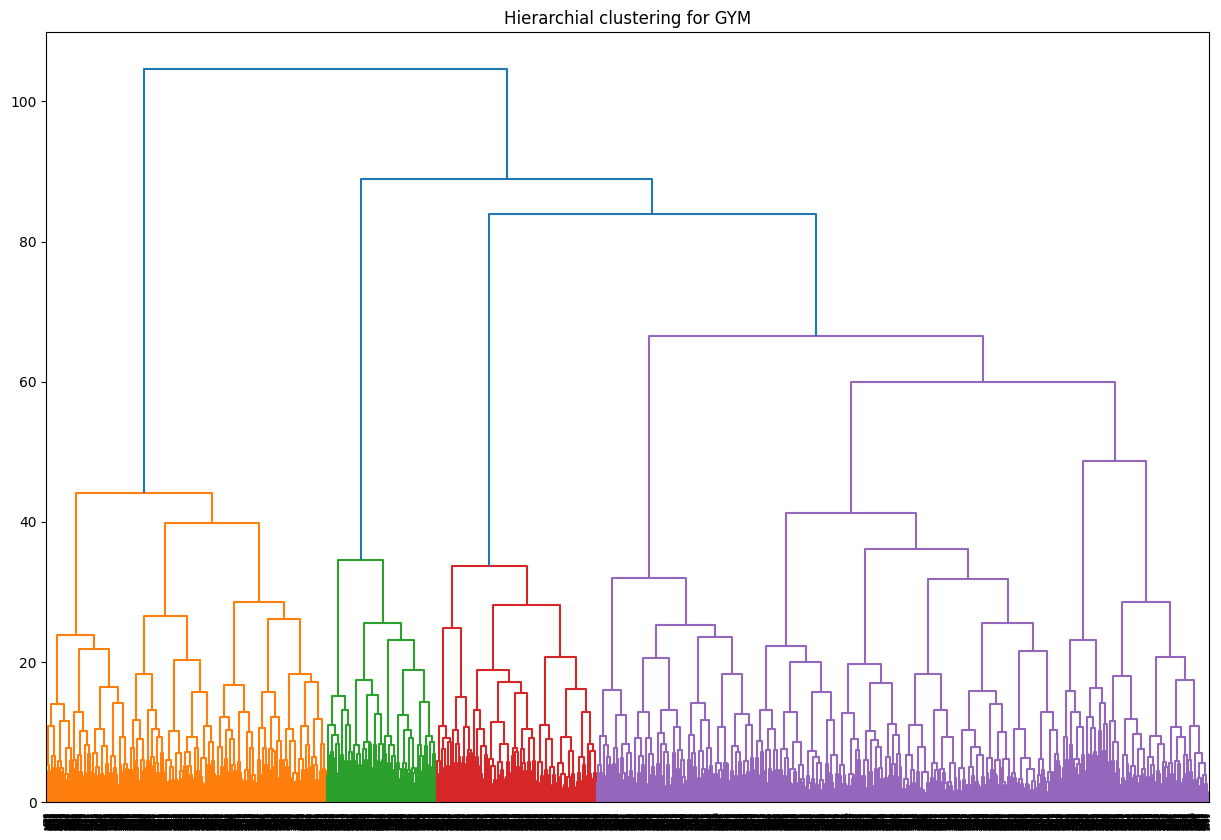

In [29]:
linked = linkage(x_sc, method = 'ward')

plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('Hierarchial clustering for GYM')
plt.show()


### Finding the optimal number of clusters (optional, not covered in the course)

Use the **Elbow Method** to determine an appropriate number of clusters (`k`) for our data.
Two metrics are calculated for each value of `k`:
- **Distortion**: Average of the minimum squared error between each point and its nearest centroid.
- **Inertia**: Sum of the squared distances between each point and its assigned centroid (already included in KMeans).

The resulting plot helps visually identify the “elbow”, where adding more clusters no longer significantly improves the metric.

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\ProgramData\anaconda3\envs\py_clean\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 108: invalid start byte


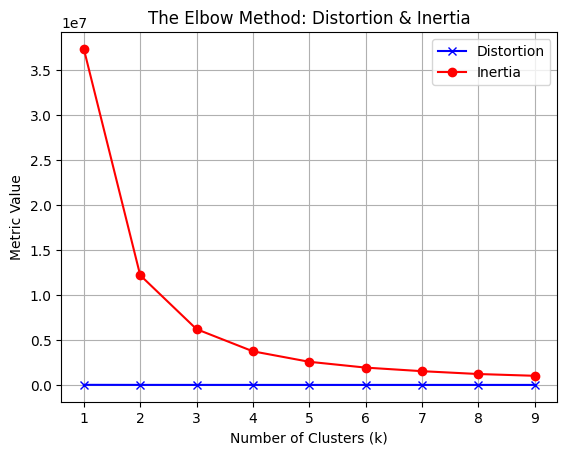

In [30]:
from scipy.spatial.distance import cdist
import numpy as np

distortions = []
inertias = []

# calculate metrics
K = range(1, 10)
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)
    
    distortions.append(
        sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0] )
    inertias.append(kmeanModel.inertia_)

# Plot both in a single plot
plt.plot(K, distortions, 'bx-', label='Distortion')
plt.plot(K, inertias, 'ro-', label='Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Metric Value')
plt.title('The Elbow Method: Distortion & Inertia')
plt.legend()
plt.grid(True)
plt.show()

The clearest bend is observed at k = 3, although the curve continues to decline until k = 5.  
Three groups is the strongest option, but 4 or 5 are also acceptable if greater detail is sought in the subgroups.

### Train clustering model with 3 groups

Silhouette_score 3 Clusters: 0.539

cluster_km
0    1664
1    1586
2     750
Name: Churn, dtype: int64



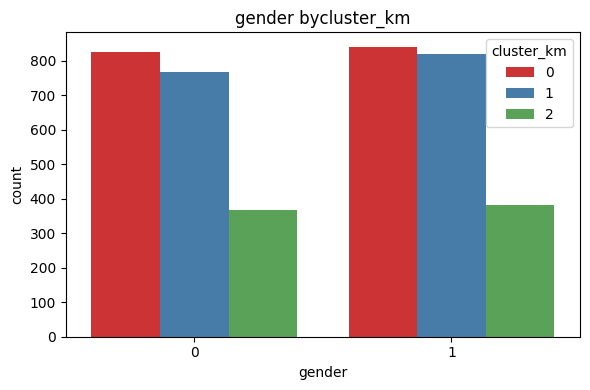

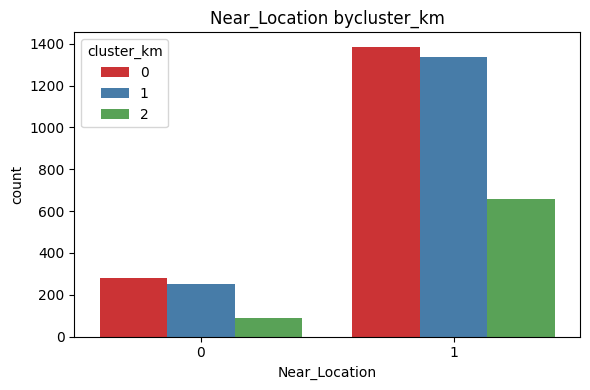

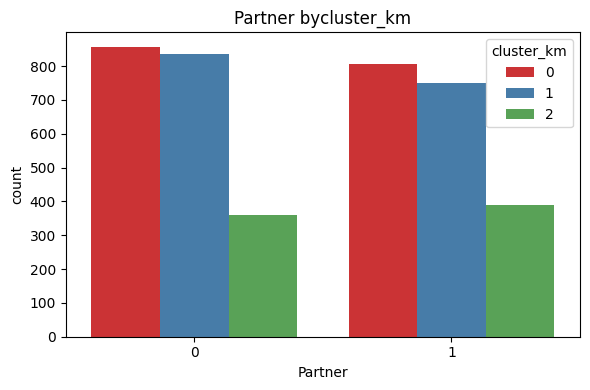

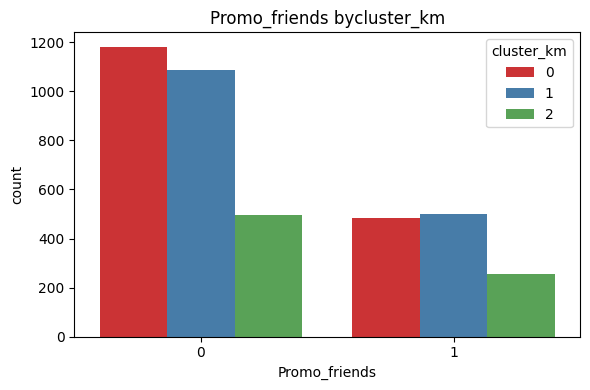

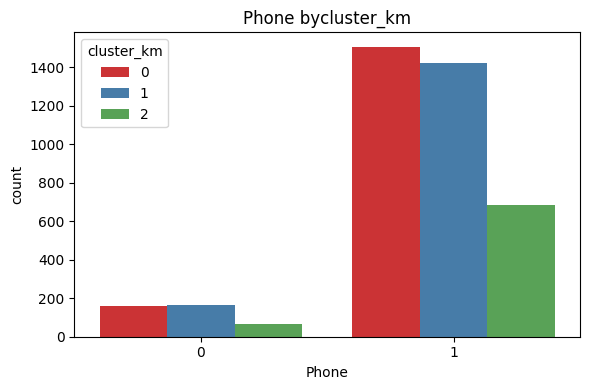

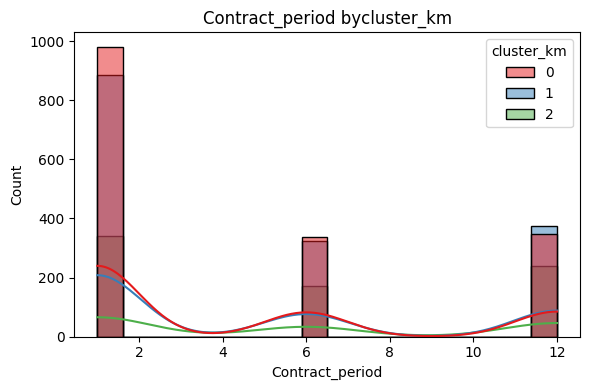

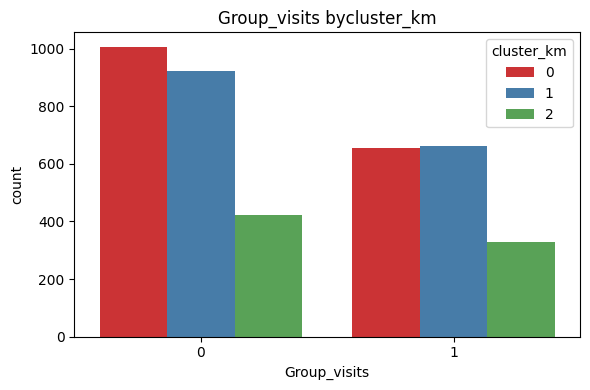

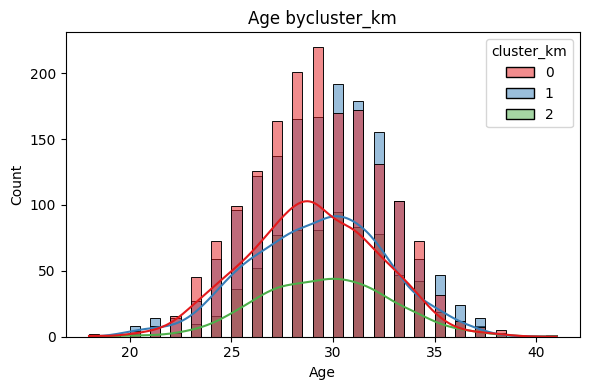

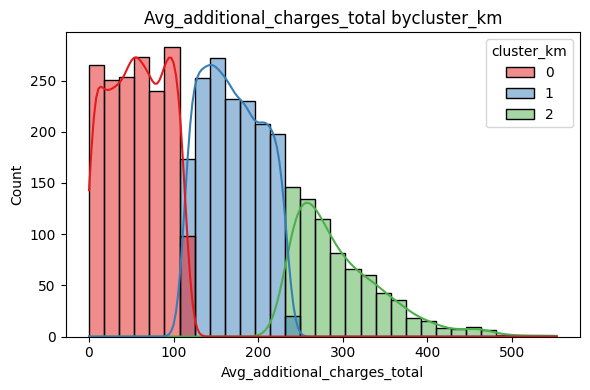

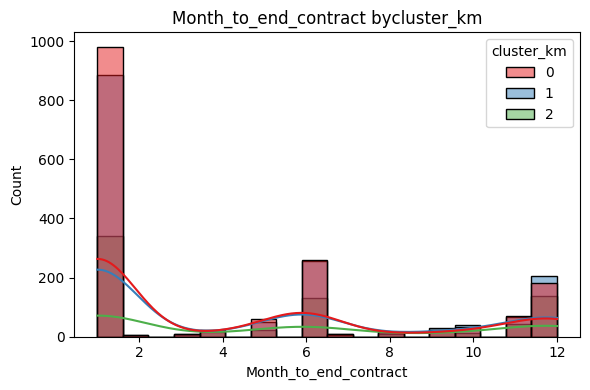

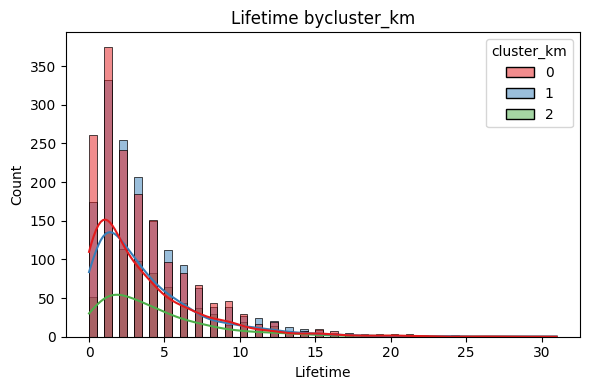

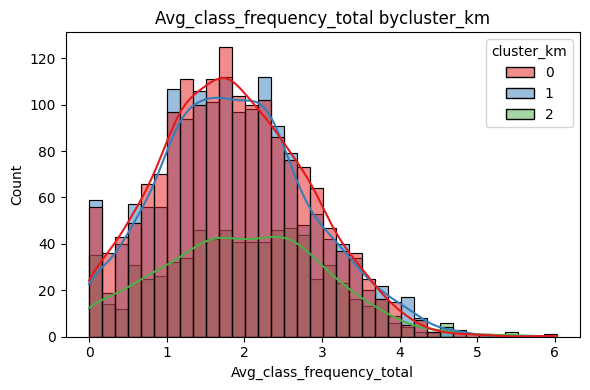

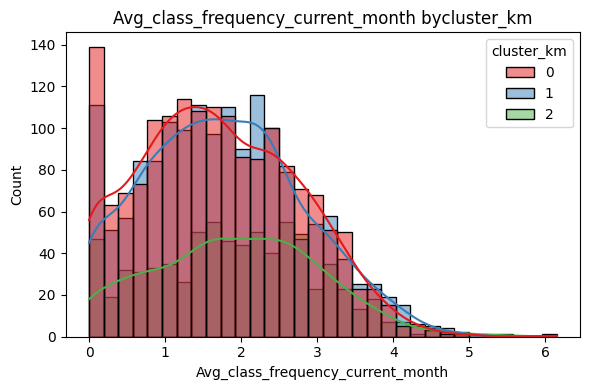

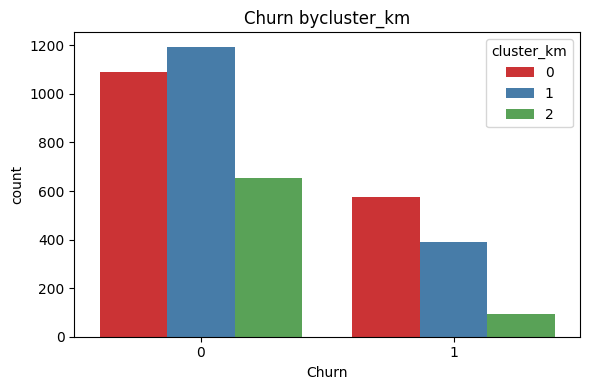

In [31]:
km = KMeans(n_clusters = 3)
labels = km.fit_predict(df.drop(columns = ['Churn']))

df['cluster_km'] = labels

# Evaluate clustering quality
print('Silhouette_score 3 Clusters:',round(silhouette_score(df, labels), 3))
print()
    
# quantity per group
print(df.groupby(['cluster_km']).count()["Churn"])
print()
    
# plot
display_graph(df, "cluster_km")


#### Train the clustering model with 5 groups

Silhouette_score 5 Clusters: 0.50009

cluster_km
0     741
1     992
2     960
3     294
4    1013
Name: Churn, dtype: int64



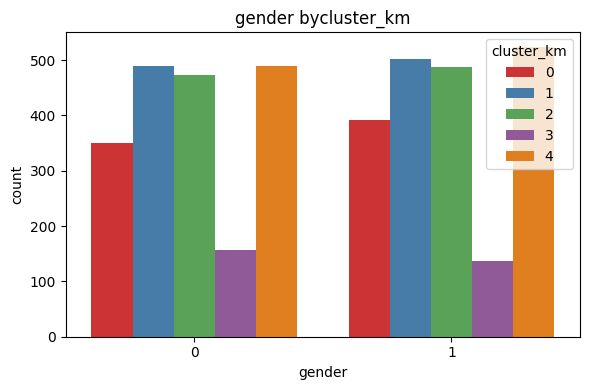

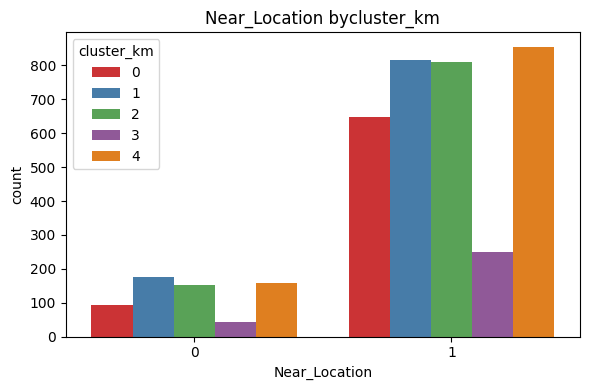

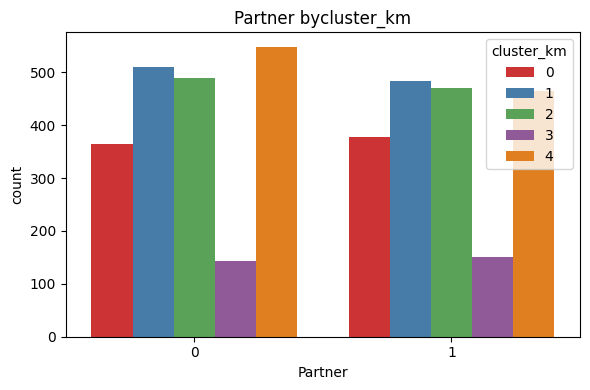

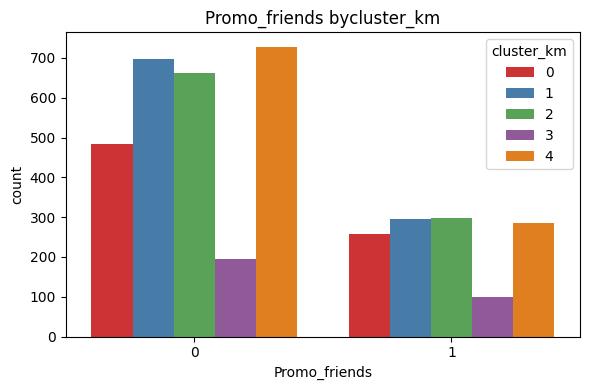

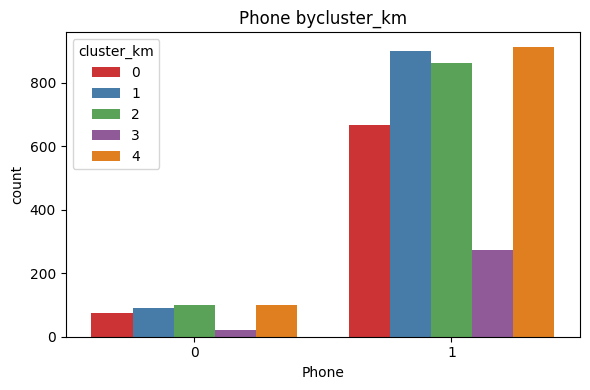

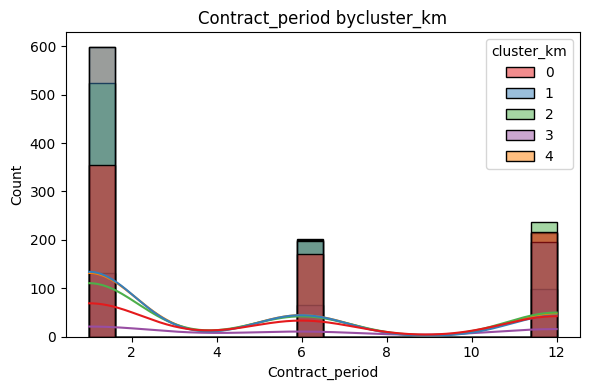

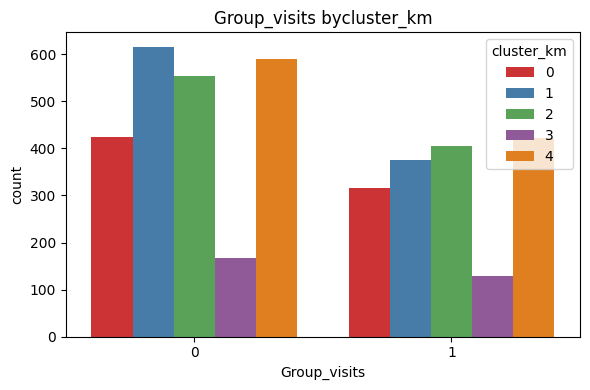

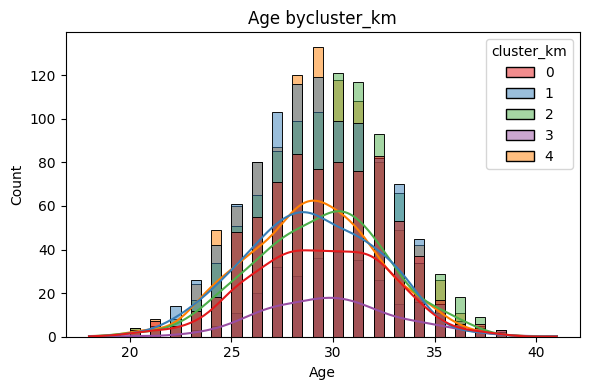

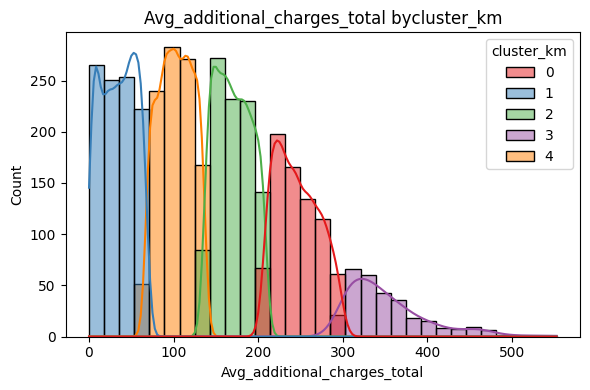

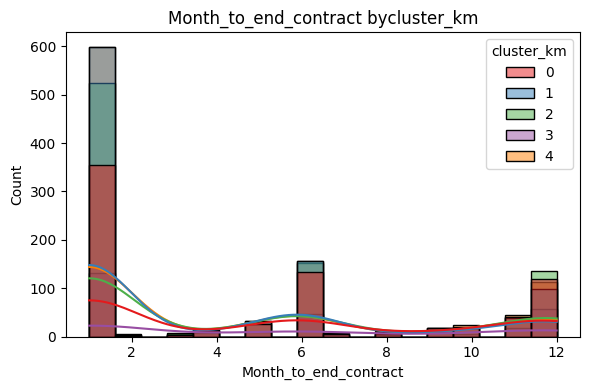

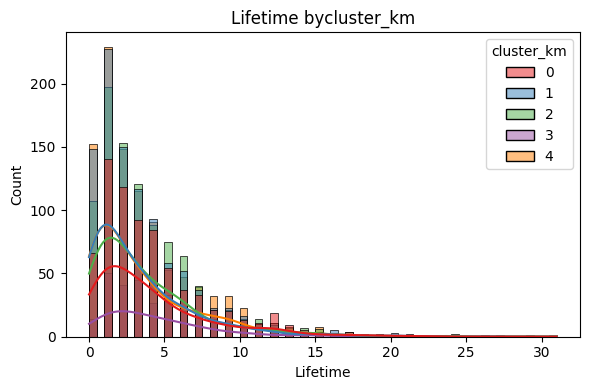

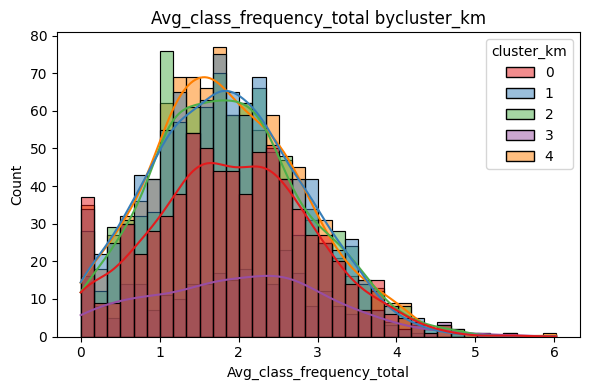

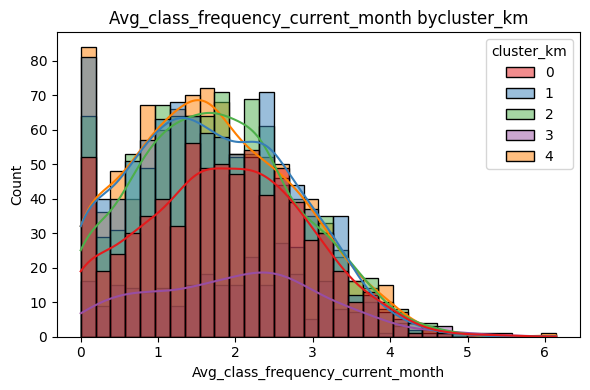

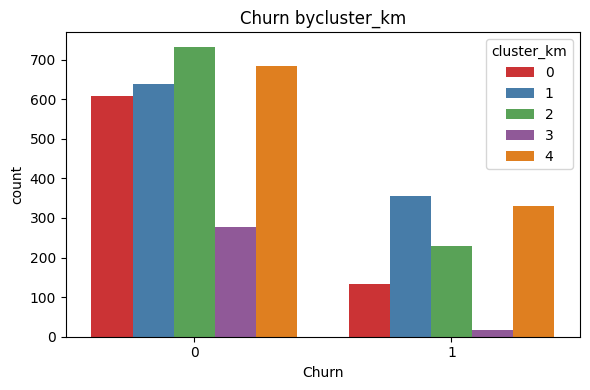

In [32]:
km = KMeans(n_clusters = 5)
labels = km.fit_predict(df.drop(columns = ['Churn']))

df['cluster_km'] = labels

# Evaluate clustering quality
print('Silhouette_score 5 Clusters:',round(silhouette_score(df, labels), 5))
print()
    
# cquantity per group
print(df.groupby(['cluster_km']).count()["Churn"])
print()
    
# plot
display_graph(df, "cluster_km")

In the development of the linear regression model, the columns `gender` and `Phone` were not included, as they showed a low relationship with the target variable, meaning they are not related to the probability of a customer staying or leaving.

The best result was obtained with `Logistic Regression`, achieving:
- Accuracy: 0.94
- Precision: 0.90
- Recall: 0.83